In [1]:
"""
WRN-28-10 em PyTorch para CIFAR-100
Porte fiel do pipeline original em TensorFlow/Keras:
  - AutoAugment (política CIFAR10, que também funciona bem em CIFAR100)
  - RandomCrop 32x32 com padding reflect 4px
  - RandomErasing
  - MixUp + CutMix (alternados por batch, desligados a partir da época 135)
  - Label Smoothing 0.1
  - SGD + Nesterov, weight decay 5e-4
  - Cosine Decay com Warmup (5 épocas)
  - Mixed Precision (AMP)
  - Checkpoint do melhor modelo por val_accuracy + EarlyStopping (patience 30)
  - CSV log por época
"""
 
import os
import json
import pickle
import numpy as np
import pandas as pd
from datetime import datetime
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
 
from sklearn.metrics import classification_report

from tqdm import tqdm


In [2]:
DATA_DIR = '/kaggle/input/datasets/marimo57/cifar-100-dataset'
OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
CONFIG = {
    'depth':           28,
    'width':           12,
    'epochs':          150,
    'batch_size':      512,
    'initial_lr':      0.2,
    'dropout':         0.3,
    'label_smoothing': 0.1,
    'warmup_epochs':   5,
    'patience':        30,
    'mixup_off_epoch': 135,   # desliga MixUp/CutMix a partir desta época (0-indexed)
}
USE_MIXUP = True
USE_CUTMIX = True
WD = 5e-4
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
 
torch.backends.cudnn.benchmark = True  # equivalente ao autotune de kernels do XLA/cuDNN


Device: cuda
GPU: Tesla T4


In [3]:
def carregar_cifar100(arquivo):
    with open(arquivo, 'rb') as f:
        return pickle.load(f, encoding='bytes')
 
 
def carregar_dados():
    treino = carregar_cifar100(os.path.join(DATA_DIR, 'train'))
    teste = carregar_cifar100(os.path.join(DATA_DIR, 'test'))
    meta = carregar_cifar100(os.path.join(DATA_DIR, 'meta'))
 
    X_treino = treino[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # NHWC uint8
    y_treino = np.array(treino[b'fine_labels'])
 
    X_teste = teste[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_teste = np.array(teste[b'fine_labels'])
 
    nomes_classes = [c.decode('utf-8') for c in meta[b'fine_label_names']]
 
    print(f"Treino : {X_treino.shape}")
    print(f"Teste  : {X_teste.shape}")
    print(f"Classes: {len(nomes_classes)}")
    return X_treino, y_treino, X_teste, y_teste, nomes_classes
 
 
class CIFAR100Dataset(Dataset):
    """Recebe arrays NHWC uint8 e aplica transform do torchvision (que espera PIL ou tensor)."""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
 
    def __len__(self):
        return len(self.images)
 
    def __getitem__(self, idx):
        img = self.images[idx]              # HWC uint8
        label = int(self.labels[idx])
        img = torch.from_numpy(img).permute(2, 0, 1).contiguous()  # CHW uint8
        if self.transform is not None:
            img = self.transform(img)
        return img, label
 
 
# Treino: pad reflect 4px + random crop 32x32 + flip + AutoAugment + normalize + RandomErasing
train_transform = transforms.Compose([
    transforms.Pad(4, padding_mode='reflect'),
    transforms.RandomCrop(32),
    transforms.RandomHorizontalFlip(),
    AutoAugment(policy=AutoAugmentPolicy.CIFAR10),
    transforms.ConvertImageDtype(torch.float32),  # uint8 -> float32 [0,1]
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.4), ratio=(0.3, 3.3), value='random'),
])
 
test_transform = transforms.Compose([
    transforms.ConvertImageDtype(torch.float32),
])
 
 
def get_dataloaders(X_treino, y_treino, X_teste, y_teste, batch_size=CONFIG['batch_size']):
    train_ds = CIFAR100Dataset(X_treino, y_treino, transform=train_transform)
    test_ds = CIFAR100Dataset(X_teste, y_teste, transform=test_transform)
 
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=4, pin_memory=True, drop_last=True, persistent_workers=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True, persistent_workers=True,
    )
    return train_loader, test_loader
 


In [4]:
def one_hot(labels, num_classes=100):
    return F.one_hot(labels, num_classes).float()
 
 
def mixup(images, labels_oh, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    images2 = images[idx]
    labels2 = labels_oh[idx]
    mixed_images = lam * images + (1 - lam) * images2
    mixed_labels = lam * labels_oh + (1 - lam) * labels2
    return mixed_images, mixed_labels
 
 
def cutmix(images, labels_oh, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    images2 = images[idx]
    labels2 = labels_oh[idx]
 
    H, W = images.shape[2], images.shape[3]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
 
    cy, cx = np.random.randint(H), np.random.randint(W)
    y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
    x1, x2 = np.clip(cx - cut_w // 2, 0, W), np.clip(cx + cut_w // 2, 0, W)
 
    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images2[:, :, y1:y2, x1:x2]
 
    lam_real = 1.0 - ((y2 - y1) * (x2 - x1) / (H * W))
    mixed_labels = lam_real * labels_oh + (1 - lam_real) * labels2
    return mixed_images, mixed_labels
 
 
def apply_mixing(images, labels, epoch, num_classes=100):
    """Retorna (images, labels_soft). labels_soft é sempre one-hot/soft para
    poder usar CrossEntropy com soft targets."""
    labels_oh = one_hot(labels, num_classes)
 
    if epoch >= CONFIG['mixup_off_epoch'] or not (USE_MIXUP or USE_CUTMIX):
        return images, labels_oh
 
    r = np.random.rand()
    if USE_MIXUP and USE_CUTMIX:
        if r < 0.5:
            return mixup(images, labels_oh)
        else:
            return cutmix(images, labels_oh)
    elif USE_MIXUP:
        return mixup(images, labels_oh)
    elif USE_CUTMIX:
        return cutmix(images, labels_oh)
    return images, labels_oh
 


In [5]:
class WideBasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1, dropout_rate=0.3):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.dropout = nn.Dropout(dropout_rate)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
 
        self.shortcut = None
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False)
 
    def forward(self, x):
        out = F.relu(self.bn1(x))
        shortcut = self.shortcut(out) if self.shortcut is not None else x
        out = self.conv1(out)
        out = F.relu(self.bn2(out))
        out = self.dropout(out)
        out = self.conv2(out)
        return out + shortcut
 
 
class WideResNet(nn.Module):
    def __init__(self, depth=28, width=10, num_classes=100, dropout_rate=0.3):
        super().__init__()
        assert (depth - 4) % 6 == 0
        n = (depth - 4) // 6
        filters = [16, 16 * width, 32 * width, 64 * width]
 
        self.conv1 = nn.Conv2d(3, filters[0], 3, padding=1, bias=False)
        self.layer1 = self._make_layer(filters[0], filters[1], n, stride=1, dropout_rate=dropout_rate)
        self.layer2 = self._make_layer(filters[1], filters[2], n, stride=2, dropout_rate=dropout_rate)
        self.layer3 = self._make_layer(filters[2], filters[3], n, stride=2, dropout_rate=dropout_rate)
        self.bn_final = nn.BatchNorm2d(filters[3])
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(filters[3], num_classes)
 
        self._init_weights()
 
    def _make_layer(self, in_planes, planes, num_blocks, stride, dropout_rate):
        layers = [WideBasicBlock(in_planes, planes, stride, dropout_rate)]
        for _ in range(num_blocks - 1):
            layers.append(WideBasicBlock(planes, planes, 1, dropout_rate))
        return nn.Sequential(*layers)
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)
 
    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn_final(out))
        out = self.avgpool(out).flatten(1)
        return self.fc(out)
 


In [6]:
def soft_ce_loss(logits, soft_targets, label_smoothing=0.1, num_classes=100):
    if label_smoothing > 0:
        soft_targets = soft_targets * (1 - label_smoothing) + label_smoothing / num_classes
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()
 
 
def topk_accuracy(logits, targets, k=5):
    _, pred = logits.topk(k, dim=1)
    correct = pred.eq(targets.view(-1, 1).expand_as(pred))
    return correct.any(dim=1).float().mean().item()
 


In [7]:
class WarmupCosineLR:
    def __init__(self, optimizer, warmup_steps, total_steps, base_lr):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.base_lr = base_lr
        self.step_num = 0
 
    def step(self):
        self.step_num += 1
        if self.step_num <= self.warmup_steps:
            lr = self.base_lr * self.step_num / max(1, self.warmup_steps)
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
            progress = min(progress, 1.0)
            lr = 0.5 * self.base_lr * (1 + np.cos(np.pi * progress))
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr

In [8]:
def train():
    X_treino, y_treino, X_teste, y_teste, nomes_classes = carregar_dados()
    
    train_loader, test_loader = get_dataloaders(
        X_treino, y_treino, X_teste, y_teste, batch_size=CONFIG['batch_size']
    )
 
    model = WideResNet(
        depth=CONFIG['depth'], width=CONFIG['width'],
        num_classes=100, dropout_rate=CONFIG['dropout'],
    ).to(DEVICE)
        
    total_params = sum(p.numel() for p in model.parameters())
    print(f"WRN-{CONFIG['depth']}-{CONFIG['width']} | Parâmetros: {total_params:,} ({total_params/1e6:.1f}M)\n")
 
    # Learning Rate ajustado proporcionalmente para o Batch de 512
    optimizer = torch.optim.SGD(
        model.parameters(), lr=CONFIG['initial_lr'], momentum=0.9,
        nesterov=True, weight_decay=WD,
    )
 
    steps_per_epoch = len(train_loader)
    total_steps = steps_per_epoch * CONFIG['epochs']
    warmup_steps = steps_per_epoch * CONFIG['warmup_epochs']
    scheduler = WarmupCosineLR(optimizer, warmup_steps, total_steps, CONFIG['initial_lr'])
 
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))
 
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_dir = os.path.join(OUTPUT_DIR, f"wrn{CONFIG['depth']}-{CONFIG['width']}_{ts}")
    ckpt_dir = os.path.join(run_dir, 'checkpoints')
    os.makedirs(ckpt_dir, exist_ok=True)
 
    best_val_acc = 0.0
    epochs_no_improve = 0
    best_state = None
    log_rows = []
 
    for epoch in range(CONFIG['epochs']):
        # ── treino ──
        model.train()
        running_loss, running_acc, n_batches = 0.0, 0.0, 0
        
        progresso_treino = tqdm(train_loader, desc=f"🏋️ Época {epoch+1}/{CONFIG['epochs']} [Treino]", leave=False)
        
        for images, labels in progresso_treino:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
 
            images, soft_targets = apply_mixing(images, labels, epoch)
 
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
                loss = soft_ce_loss(logits, soft_targets, CONFIG['label_smoothing'])
 
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
 
            with torch.no_grad():
                preds = logits.argmax(dim=1)
                hard_targets = soft_targets.argmax(dim=1)
                acc = (preds == hard_targets).float().mean().item()
 
            running_loss += loss.item()
            running_acc += acc
            n_batches += 1
            
            progresso_treino.set_postfix(loss=f"{loss.item():.4f}")
 
        train_loss = running_loss / n_batches
        train_acc = running_acc / n_batches
 
        # ── validação ──
        model.eval()
        val_acc, val_loss, v_batches = 0.0, 0.0, 0
        
        progresso_val = tqdm(test_loader, desc=f"🔍 Época {epoch+1}/{CONFIG['epochs']} [Val]", leave=False)
        
        with torch.no_grad():
            for images, labels in progresso_val:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                    logits = model(images)
                    loss = F.cross_entropy(logits, labels)  # loss "pura", sem mixup/label smoothing

                preds = logits.argmax(dim=1)
                val_acc += (preds == labels).float().mean().item()
                val_loss += loss.item()
                v_batches += 1

        val_acc /= v_batches
        val_loss /= v_batches
 
        lr_atual = optimizer.param_groups[0]['lr']
        log_rows.append({
            'epoch': epoch + 1, 'accuracy': train_acc, 'loss': train_loss,
            'top5_accuracy': 0.0, 'val_accuracy': val_acc,
            'val_loss': 0.0, 'val_top5_accuracy': 0.0, 'lr': lr_atual,
        })
 
        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            epochs_no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, os.path.join(ckpt_dir, 'best_model.pt'))
        else:
            epochs_no_improve += 1
 
        tag = "melhorou" if improved else "sem melhora"
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} | acc={train_acc*100:.2f}% | val_acc={val_acc*100:.2f}% | lr={lr_atual:.5f} | {tag} (best={best_val_acc*100:.2f}%)")
 
        if epochs_no_improve >= CONFIG['patience']:
            print(f"Early stopping na época {epoch+1}.")
            break
 
    if best_state is not None:
        model.load_state_dict(best_state)
 
    pd.DataFrame(log_rows).to_csv(os.path.join(run_dir, 'training_log.csv'), index=False)
    return model, test_loader, y_teste, nomes_classes, run_dir

In [9]:
def avaliar(model, test_loader, y_teste, nomes_classes, run_dir):
    model.eval()
    all_logits, all_preds = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
            all_logits.append(logits.float().cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
 
    y_pred_probs = torch.softmax(torch.cat(all_logits), dim=1).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_true = y_teste
 
    report = classification_report(y_true, y_pred, target_names=nomes_classes, output_dict=True)
 
    test_acc = (y_pred == y_true).mean()
    top5_correct = np.array([
        y_true[i] in np.argsort(y_pred_probs[i])[-5:] for i in range(len(y_true))
    ])
    test_top5 = top5_correct.mean()
    test_loss = -np.log(np.clip(y_pred_probs[np.arange(len(y_true)), y_true], 1e-8, 1.0)).mean()
 
    metricas = pd.DataFrame({
        'Métrica': ['Loss', 'Top-1 Accuracy', 'Top-5 Accuracy',
                    'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
        'Valor': [test_loss, test_acc, test_top5,
                  report['macro avg']['precision'],
                  report['macro avg']['recall'],
                  report['macro avg']['f1-score']],
    })
    metricas['Valor'] = metricas['Valor'].apply(
        lambda x: f'{x*100:.2f}%' if x <= 1 else f'{x:.4f}'
    )
    print(metricas)
 
    with open(os.path.join(run_dir, 'final_metrics.json'), 'w') as f:
        json.dump({
            'loss': float(test_loss),
            'accuracy': float(test_acc),
            'top5_accuracy': float(test_top5),
        }, f, indent=2)
 
    torch.save(model.state_dict(), os.path.join(run_dir, 'final_model.pt'))
    print(f"Modelo salvo em: {run_dir}")
 
    return y_pred, y_pred_probs, y_true, metricas
 
 
if __name__ == '__main__':
    model, test_loader, y_teste, nomes_classes, run_dir = train()
    avaliar(model, test_loader, y_teste, nomes_classes, run_dir)
 


Treino : (50000, 32, 32, 3)
Teste  : (10000, 32, 32, 3)
Classes: 100
WRN-28-12 | Parâmetros: 52,587,060 (52.6M)



Epoch 1/150 | acc=1.31% | val_acc=3.76% | lr=0.04000 | melhorou (best=3.76%)


Epoch 2/150 | acc=4.22% | val_acc=9.45% | lr=0.08000 | melhorou (best=9.45%)


Epoch 3/150 | acc=6.68% | val_acc=12.65% | lr=0.12000 | melhorou (best=12.65%)


Epoch 4/150 | acc=9.40% | val_acc=18.45% | lr=0.16000 | melhorou (best=18.45%)


...

Epoch 146/150 | acc=91.98% | val_acc=84.99% | lr=0.00038 | sem melhora (best=85.07%)


Epoch 147/150 | acc=91.95% | val_acc=85.05% | lr=0.00021 | sem melhora (best=85.07%)


Epoch 148/150 | acc=91.87% | val_acc=84.97% | lr=0.00009 | sem melhora (best=85.07%)


Epoch 149/150 | acc=91.96% | val_acc=84.90% | lr=0.00002 | sem melhora (best=85.07%)


Epoch 150/150 | acc=92.42% | val_acc=84.92% | lr=0.00000 | sem melhora (best=85.07%)
           Métrica   Valor
0             Loss  63.85%
1   Top-1 Accuracy  85.08%
2   Top-5 Accuracy  97.03%
3  Macro Precision  85.25%
4     Macro Recall  85.08%
5   Macro F1-Score  85.08%
Modelo salvo em: /kaggle/working/outputs/wrn28-12_20260703_142615


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

OUT_DIR = os.path.join(run_dir, 'relatorio')
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Relatório será salvo em: {OUT_DIR}")

Relatório será salvo em: /kaggle/working/outputs/wrn28-12_20260703_142615/relatorio


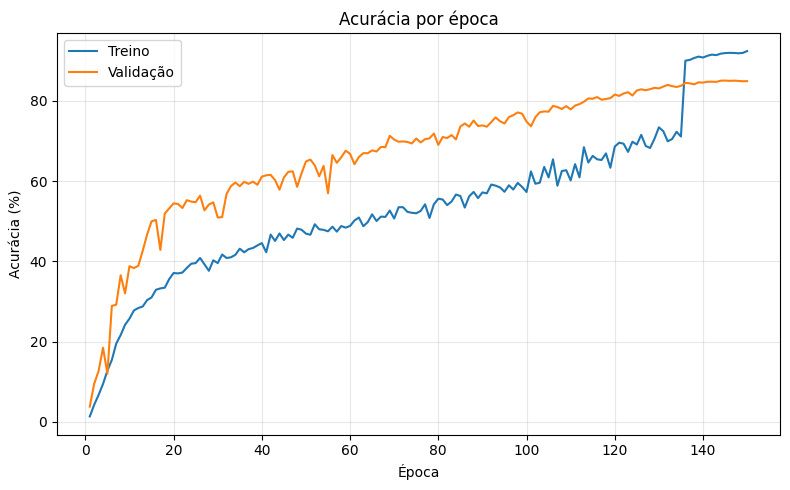

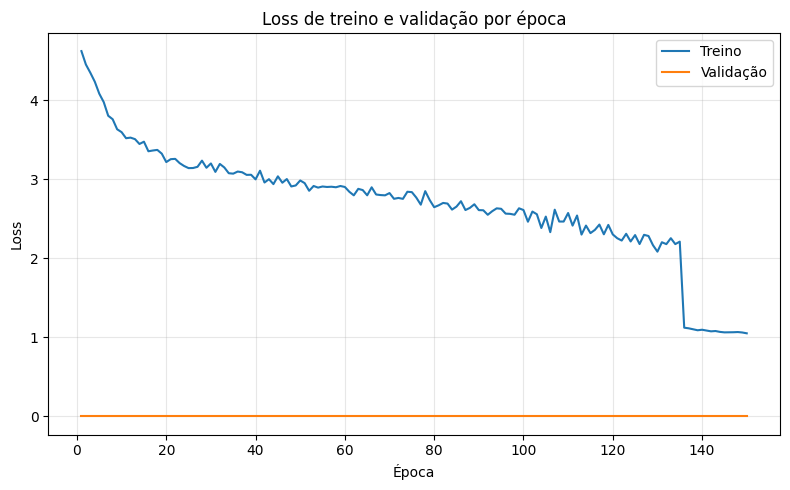

In [11]:
log_df = pd.read_csv(os.path.join(run_dir, 'training_log.csv'))

# Acurácia
plt.figure(figsize=(8, 5))
plt.plot(log_df['epoch'], log_df['accuracy'] * 100, label='Treino')
plt.plot(log_df['epoch'], log_df['val_accuracy'] * 100, label='Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.title('Acurácia por época')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'accuracy.png'), dpi=150)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(log_df['epoch'], log_df['loss'], label='Treino')
plt.plot(log_df['epoch'], log_df['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss de treino e validação por época')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'loss.png'), dpi=150)
plt.show()

In [12]:
y_pred, y_pred_probs, y_true, metricas = avaliar(model, test_loader, y_teste, nomes_classes, run_dir)

# imagens cruas (uint8, HWC) já carregadas dentro do dataset do test_loader
X_teste = test_loader.dataset.images

print(metricas)

           Métrica   Valor
0             Loss  63.85%
1   Top-1 Accuracy  85.08%
2   Top-5 Accuracy  97.03%
3  Macro Precision  85.25%
4     Macro Recall  85.08%
5   Macro F1-Score  85.08%
Modelo salvo em: /kaggle/working/outputs/wrn28-12_20260703_142615
           Métrica   Valor
0             Loss  63.85%
1   Top-1 Accuracy  85.08%
2   Top-5 Accuracy  97.03%
3  Macro Precision  85.25%
4     Macro Recall  85.08%
5   Macro F1-Score  85.08%


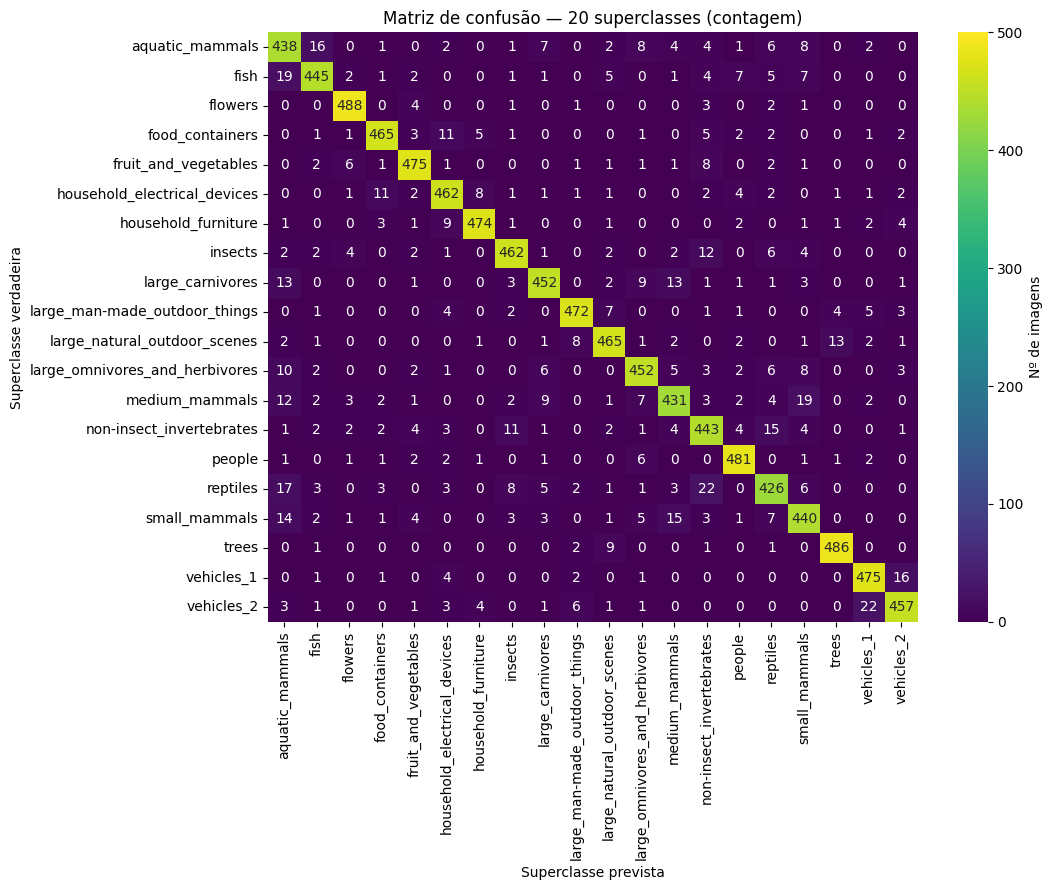

,superclasse,acuracia
2,flowers,0.976
17,trees,0.972
14,people,0.962
4,fruit_and_vegetables,0.950
18,vehicles_1,0.950
6,household_furniture,0.948
9,large_man-made_outdoor_things,0.944
3,food_containers,0.930
10,large_natural_outdoor_scenes,0.930
7,insects,0.924


In [13]:
# ── Matriz de confusão por SUPERCLASSE (20 categorias) ──

teste_raw = carregar_cifar100(os.path.join(DATA_DIR, 'test'))
meta_raw = carregar_cifar100(os.path.join(DATA_DIR, 'meta'))

y_true_coarse = np.array(teste_raw[b'coarse_labels'])
nomes_superclasses = [c.decode('utf-8') for c in meta_raw[b'coarse_label_names']]

# mapa classe fina -> superclasse (cada classe fina pertence a só 1 superclasse)
fine_to_coarse = {}
for f, c in zip(teste_raw[b'fine_labels'], teste_raw[b'coarse_labels']):
    fine_to_coarse[f] = c

# traduz as predições do modelo (classe fina) para superclasse
y_pred_coarse = np.array([fine_to_coarse[p] for p in y_pred])

cm_coarse = confusion_matrix(y_true_coarse, y_pred_coarse, labels=range(20))

# cada superclasse tem 5 classes finas x 100 imagens/teste = 500 imagens no total
plt.figure(figsize=(11, 9))
sns.heatmap(cm_coarse, xticklabels=nomes_superclasses, yticklabels=nomes_superclasses,
            cmap='viridis', annot=True, fmt='d', cbar_kws={'label': 'Nº de imagens'},
            vmin=0, vmax=500)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel('Superclasse prevista')
plt.ylabel('Superclasse verdadeira')
plt.title('Matriz de confusão — 20 superclasses (contagem)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'matriz_confusao_superclasses.png'), dpi=150)
plt.show()

# acurácia agregada por superclasse, ordenada
acc_por_superclasse = cm_coarse.diagonal() / cm_coarse.sum(axis=1)
df_super = pd.DataFrame({
    'superclasse': nomes_superclasses,
    'acuracia': acc_por_superclasse,
}).sort_values('acuracia', ascending=False)
df_super.to_csv(os.path.join(OUT_DIR, 'tabela_por_superclasse.csv'), index=False)
df_super

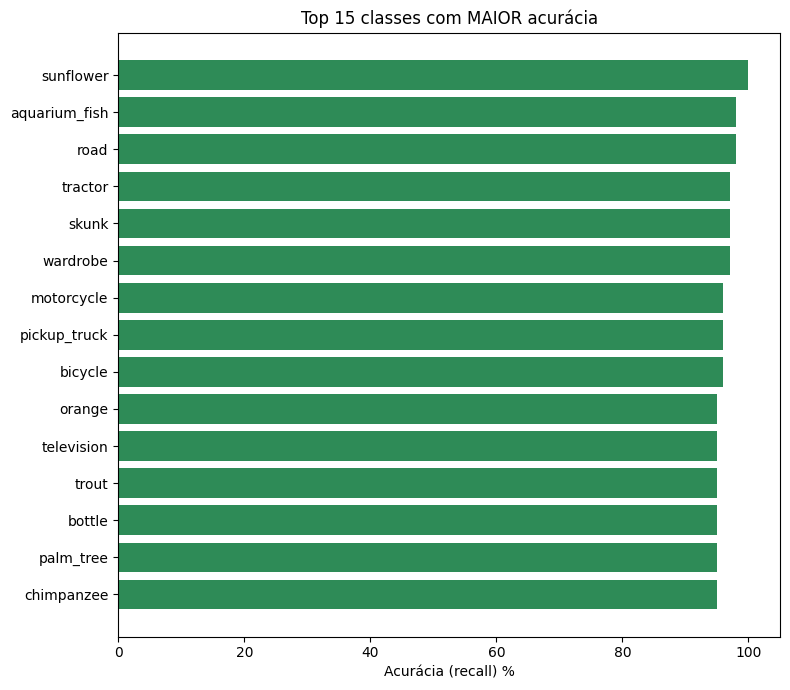

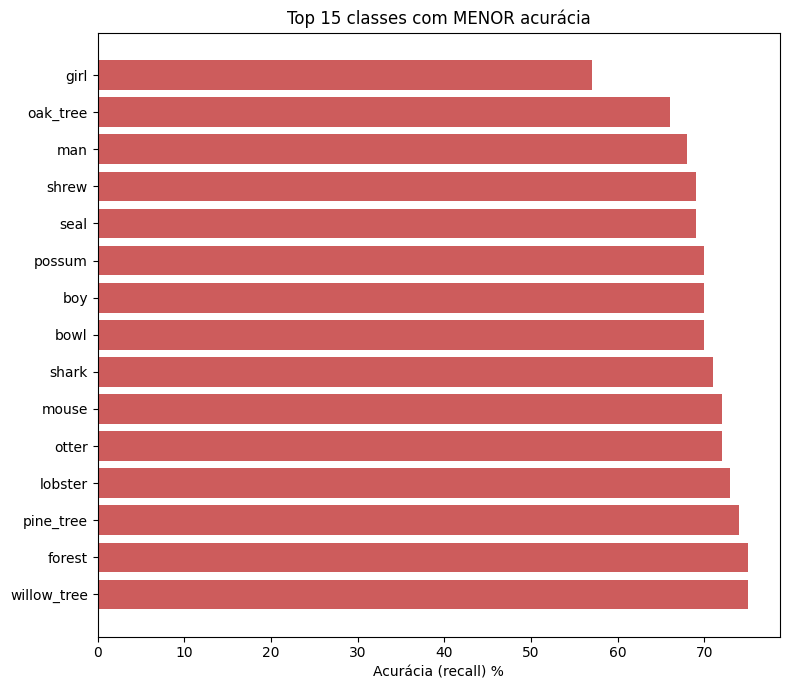

,classe,precision,recall,f1-score,support
82,sunflower,0.952381,1.00,0.975610,100.0
1,aquarium_fish,0.942308,0.98,0.960784,100.0
68,road,0.890909,0.98,0.933333,100.0
89,tractor,0.915094,0.97,0.941748,100.0
75,skunk,0.950980,0.97,0.960396,100.0
...,...,...,...,...,...
72,seal,0.657143,0.69,0.673171,100.0
74,shrew,0.690000,0.69,0.690000,100.0
46,man,0.647619,0.68,0.663415,100.0
52,oak_tree,0.680412,0.66,0.670051,100.0


In [14]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=nomes_classes, output_dict=True)
df_classes = pd.DataFrame(report).T.iloc[:100].reset_index().rename(columns={'index': 'classe'})
df_classes.to_csv(os.path.join(OUT_DIR, 'tabela_por_classe.csv'), index=False)

top_acerto = df_classes.sort_values('recall', ascending=False).head(15)
top_erro = df_classes.sort_values('recall', ascending=True).head(15)

plt.figure(figsize=(8, 7))
plt.barh(top_acerto['classe'], top_acerto['recall'] * 100, color='seagreen')
plt.xlabel('Acurácia (recall) %')
plt.title('Top 15 classes com MAIOR acurácia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'top_classes_acerto.png'), dpi=150)
plt.show()

plt.figure(figsize=(8, 7))
plt.barh(top_erro['classe'], top_erro['recall'] * 100, color='indianred')
plt.xlabel('Acurácia (recall) %')
plt.title('Top 15 classes com MENOR acurácia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'top_classes_erro.png'), dpi=150)
plt.show()

df_classes.sort_values('recall', ascending=False)

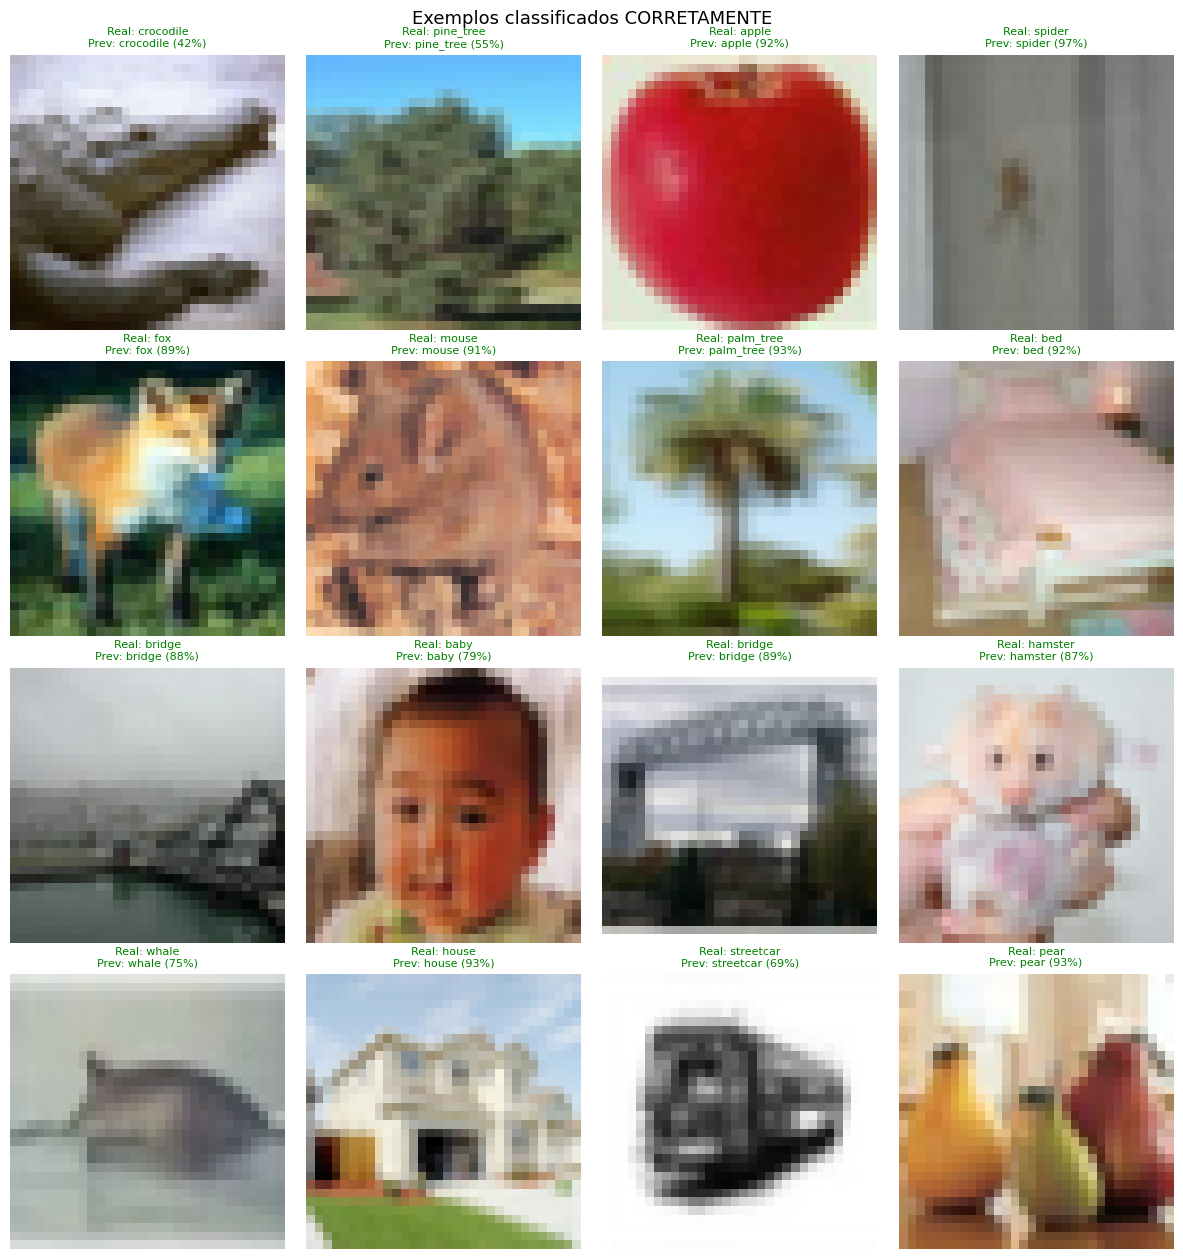

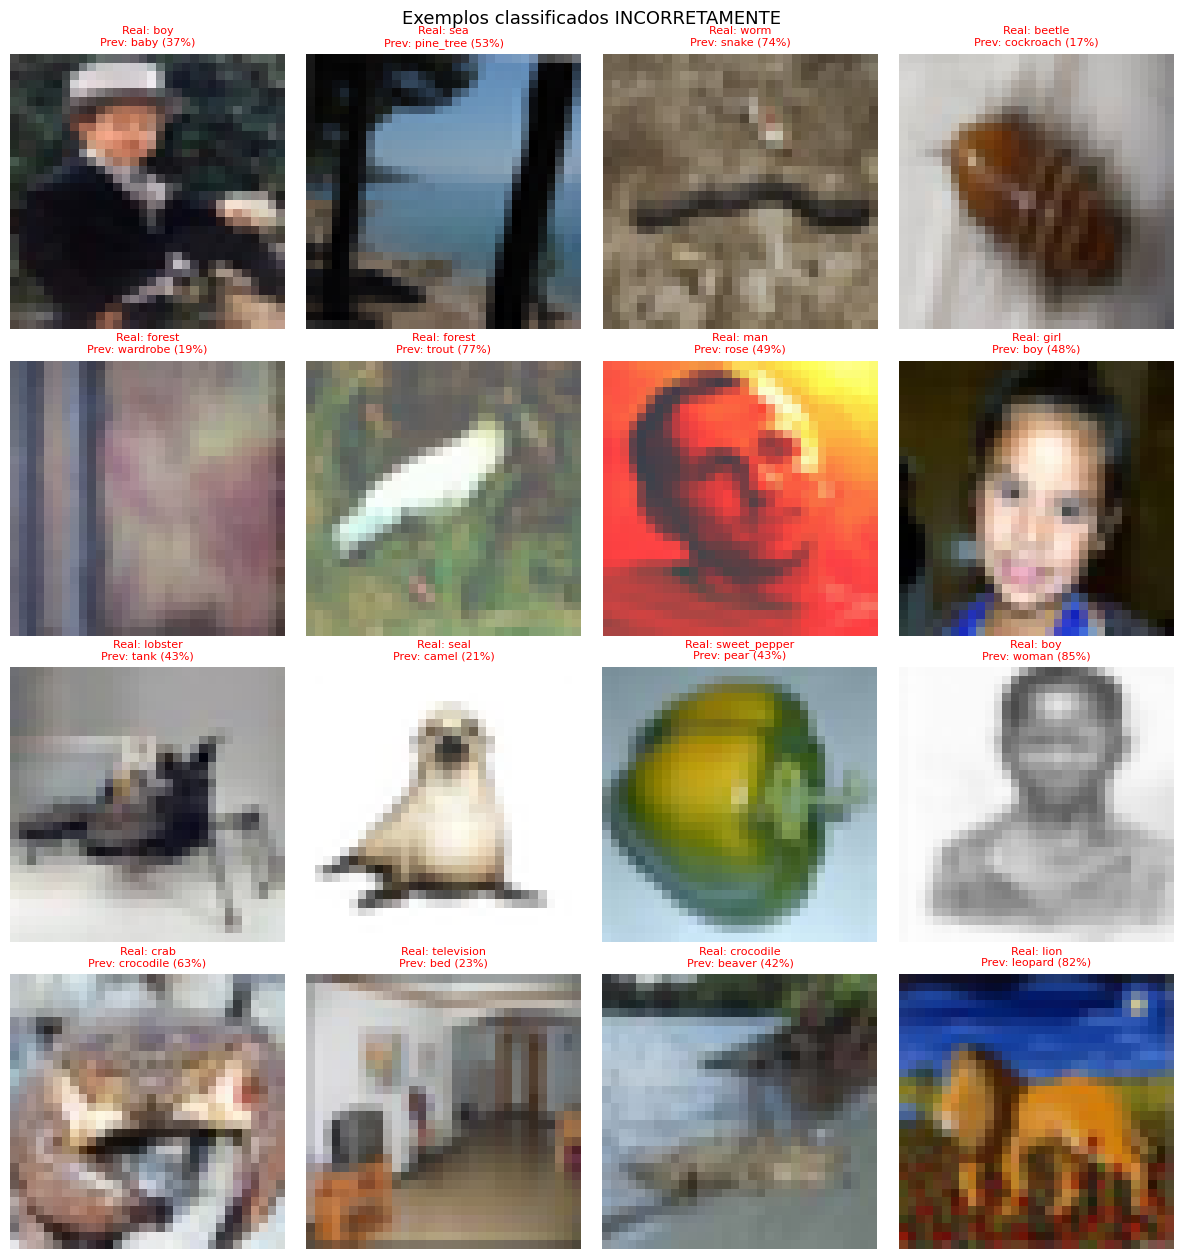

Total de erros no conjunto de teste: 1492 / 10000


In [15]:
np.random.seed(42)

def mostrar_grid(indices, titulo, arquivo):
    cols = 4
    rows = int(np.ceil(len(indices) / cols))
    plt.figure(figsize=(cols * 3, rows * 3.2))
    for i, idx in enumerate(indices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X_teste[idx])
        plt.axis('off')
        verdadeiro = nomes_classes[y_true[idx]]
        previsto = nomes_classes[y_pred[idx]]
        conf = y_pred_probs[idx, y_pred[idx]] * 100
        cor = 'green' if y_true[idx] == y_pred[idx] else 'red'
        plt.title(f"Real: {verdadeiro}\nPrev: {previsto} ({conf:.0f}%)", fontsize=8, color=cor)
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, arquivo), dpi=150)
    plt.show()

acertos_idx = np.where(y_true == y_pred)[0]
erros_idx = np.where(y_true != y_pred)[0]

amostra_acertos = np.random.choice(acertos_idx, size=16, replace=False)
amostra_erros = np.random.choice(erros_idx, size=min(16, len(erros_idx)), replace=False)

mostrar_grid(amostra_acertos, 'Exemplos classificados CORRETAMENTE', 'exemplos_acertos.png')
mostrar_grid(amostra_erros, 'Exemplos classificados INCORRETAMENTE', 'exemplos_erros.png')

print(f"Total de erros no conjunto de teste: {len(erros_idx)} / {len(y_true)}")